In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed_market/processed_EURUSD_H1_20200101_20260131.csv", index_col="time", parse_dates=["time"])

df.head()

,Open,High,Low,Close,Volume,TRIX_30_9,VWAP_D,ROC_10,RSI_14,ATRr_14,...,BBP_5_2.0_2.0,CCI_14_0.015,TSI_13_25_13,STOCHRSIk_14_14_3_3,ADX_14,DMP_14,DMN_14,STOCHk_14_3_3,STOCHh_14_3_3,Target
time,,,,,,,,,,,,,,,,,,,,,
2020-01-07 22:00:00+00:00,1.11519,1.11534,1.11441,1.11476,1150,-0.000627,1.116562,-0.243405,37.577962,0.000995,...,0.610181,-36.428892,-29.141166,45.404353,35.597813,0.001988,0.003742,25.178571,2.953582,0
2020-01-07 23:00:00+00:00,1.11473,1.11543,1.11464,1.11541,2426,-0.001033,1.116489,-0.019720,43.262676,0.000980,...,0.859166,-12.398750,-26.848535,62.526554,35.085621,0.001936,0.003474,32.098271,5.235909,2
2020-01-08 00:00:00+00:00,1.11540,1.11682,1.11526,1.11587,5297,-0.001396,1.115983,0.097777,46.945033,0.001021,...,0.865027,49.497412,-23.778251,74.697223,32.622108,0.003188,0.003226,37.633753,5.996888,1
2020-01-08 01:00:00+00:00,1.11587,1.11633,1.11549,1.11557,3900,-0.001729,1.115904,0.126553,44.898418,0.001009,...,0.642708,59.218251,-21.824050,88.270651,30.334560,0.002960,0.002996,44.152570,6.191039,2
2020-01-08 02:00:00+00:00,1.11558,1.11614,1.11531,1.11586,3508,-0.002024,1.115867,0.194848,47.290610,0.000996,...,0.724996,84.853079,-19.484145,95.293830,28.434208,0.002749,0.002962,50.015138,6.081317,2


### Correlation Between Indicators


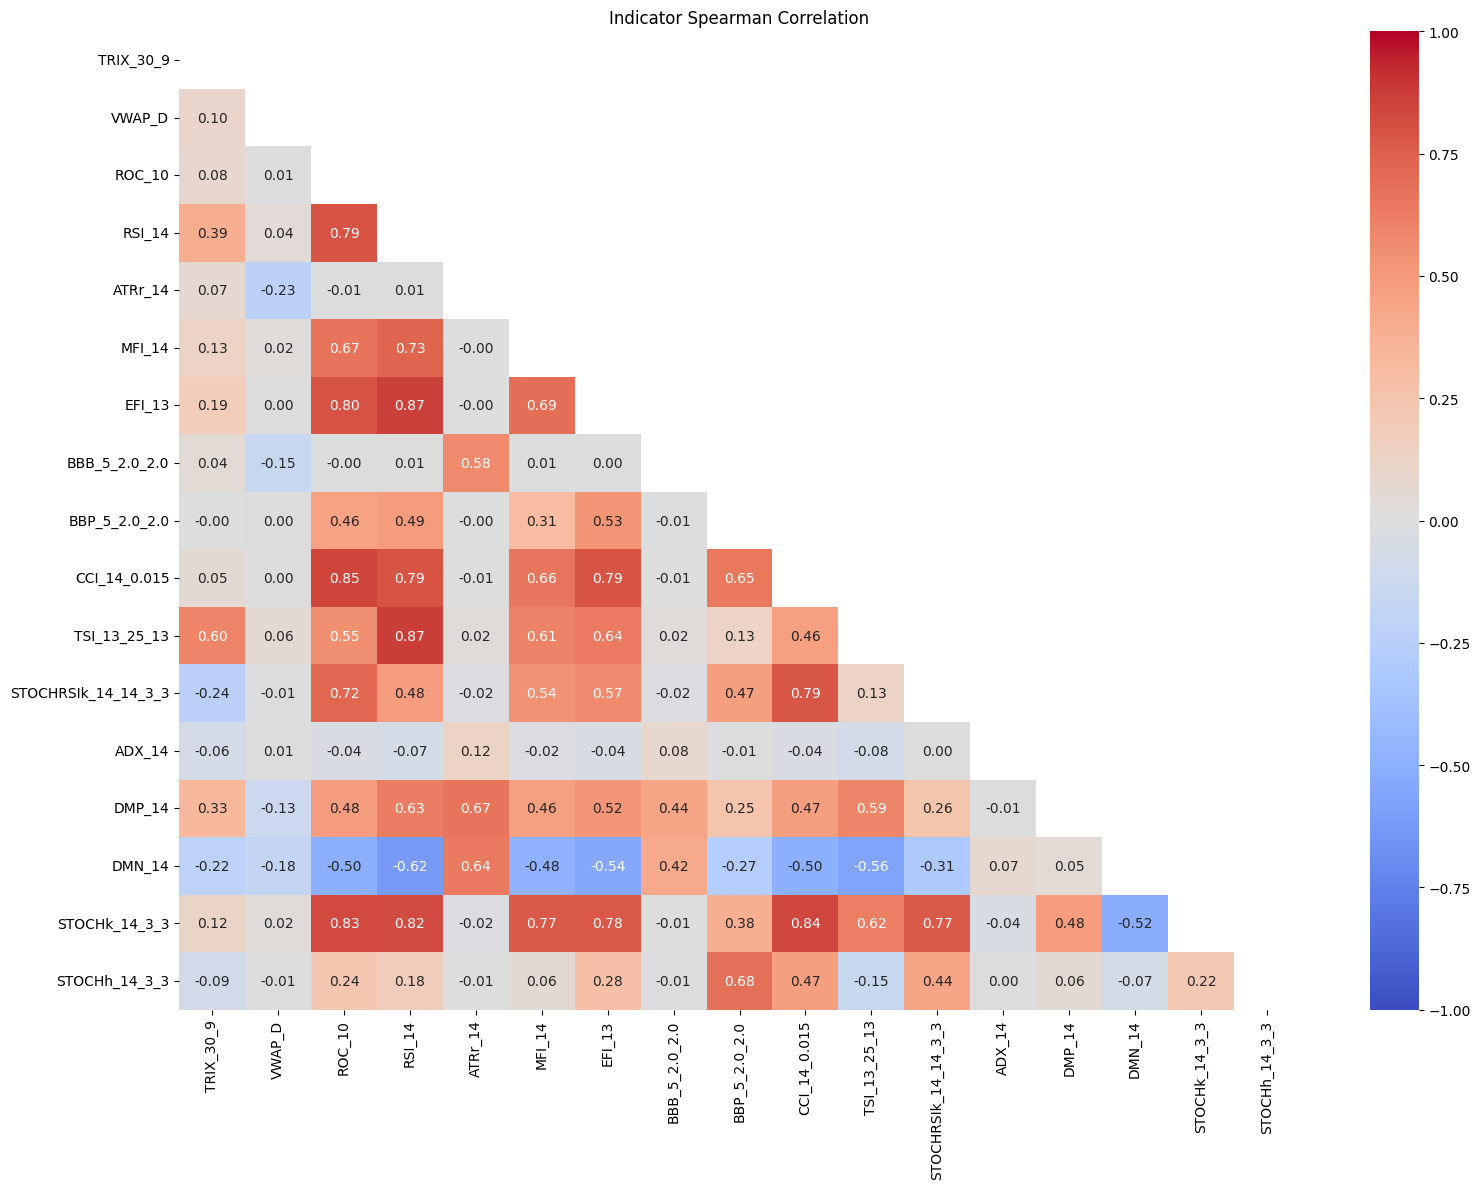

In [35]:
drop_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
indicator_cols = [col for col in df.columns if col not in drop_cols and col != "Time"]

plt.figure(figsize=(16, 12))

# compute Spearman correlation matrix for technical indicators
corr_matrix = df[indicator_cols].corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Indicator Spearman Correlation")
plt.tight_layout()
plt.show()


### Target Distribution Verification

In [36]:
class_counts = df["Target"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution (%):")
print(f"0 (Up):      {class_counts.get(0, 0):.2f}%")
print(f"1 (Down):    {class_counts.get(1, 0):.2f}%")
print(f"2 (Unknown): {class_counts.get(2, 0):.2f}%")

Class Distribution (%):
0 (Up):      35.00%
1 (Down):    30.00%
2 (Unknown): 35.00%
